In [1]:
import pandas as pd
import re
import struct
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

import matplotlib.colors as mcolors

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']


##  Data reading

In [ ]:
run_base     = 'Run172SPheCH'   # prefix; per-channel run dirs: Run172SPheCH1, Run172SPheCH2, ...
temperature  = 6
pressure     = 8.5

In [ ]:
# --- All 4 channels are processed together ---
all_channels = ['CH1', 'CH2', 'CH3', 'CH4']

nchannels       = 1 # per file
nevents_per_wvf = 2000

samples_per_waveform = 124
# samples_per_waveform = 752

event_header_bytes = 28
# event_header_bytes = 3036

# sample_binning = 1
sample_binning = 8e-9

nfiles = 60
start  = 1


In [4]:
fixBaselines_Amp = {'CH1': -559
                    ,'CH2': -610
                    ,'CH3': -586
                    ,'CH4': -581
                    }


In [5]:
# Read data for all 4 channels and merge into a single DataFrame
# Each channel lives in its own run directory (Run172SPheCH1, ..., Run172SPheCH4).
# parse_data returns a column named 'CH1'; we rename it to the correct channel name.

channel_dfs = {}

for ch_idx, ch in enumerate(all_channels):
    channel_num = ch_idx + 1
    run         = f'{run_base}{channel_num}'
    run_dir     = f'/home/marian/CIGAR_ANALYSIS/CIGAR/data/{run}'

    dataframes = []
    for i, file in enumerate(tqdm(os.listdir(run_dir)[start:nfiles],
                                   desc=f'Reading {ch} .bin files', unit='file')):
        if file.endswith('.bin'):
            file_path = os.path.join(run_dir, file)
            df_tmp = parse_data.parse_wf_from_binary(
                file_path,
                channels=nchannels,
                n_events=nevents_per_wvf,
                file_idx=i,
                event_header_bytes=event_header_bytes
            )
            dataframes.append(df_tmp)

    ch_df = pd.concat(dataframes, ignore_index=True)
    ch_df.rename(columns={'CH1': ch}, inplace=True)   # parse_data always returns 'CH1'
    channel_dfs[ch] = ch_df

# Merge all channels on event + TIME (they share the same event structure)
df = channel_dfs['CH1'][['event', 'TIME', 'CH1']].copy()
for ch in ['CH2', 'CH3', 'CH4']:
    df = df.merge(channel_dfs[ch][['event', 'TIME', ch]], on=['event', 'TIME'], how='inner')

print(f'Merged DataFrame shape: {df.shape}')
df.tail()


Reading CH4 .bin files: 100%|██████████| 31/31 [00:12<00:00,  2.51file/s]


Merged DataFrame shape: (6448000, 6)


,event,TIME,CH1,CH2,CH3,CH4
6447995,51999,9.600000e-07,-550.200745,-288.080170,-561.899109,-721.913757
6447996,51999,9.680000e-07,-551.669067,-303.484528,-539.143433,-719.329956
6447997,51999,9.760000e-07,-547.631104,-317.293243,-544.663696,-726.650635
6447998,51999,9.840000e-07,-541.818909,-328.524323,-564.904541,-735.140076
6447999,51999,9.920000e-07,-538.943420,-339.694031,-580.667908,-730.526245


##  Data selection

In [6]:
event_list = df['event'].unique()
nevents    = len(event_list)
print(f'Total nevents = {nevents}')


Total nevents = 52000


In [7]:
channels = all_channels   # ['CH1', 'CH2', 'CH3', 'CH4']

selected_event = 50


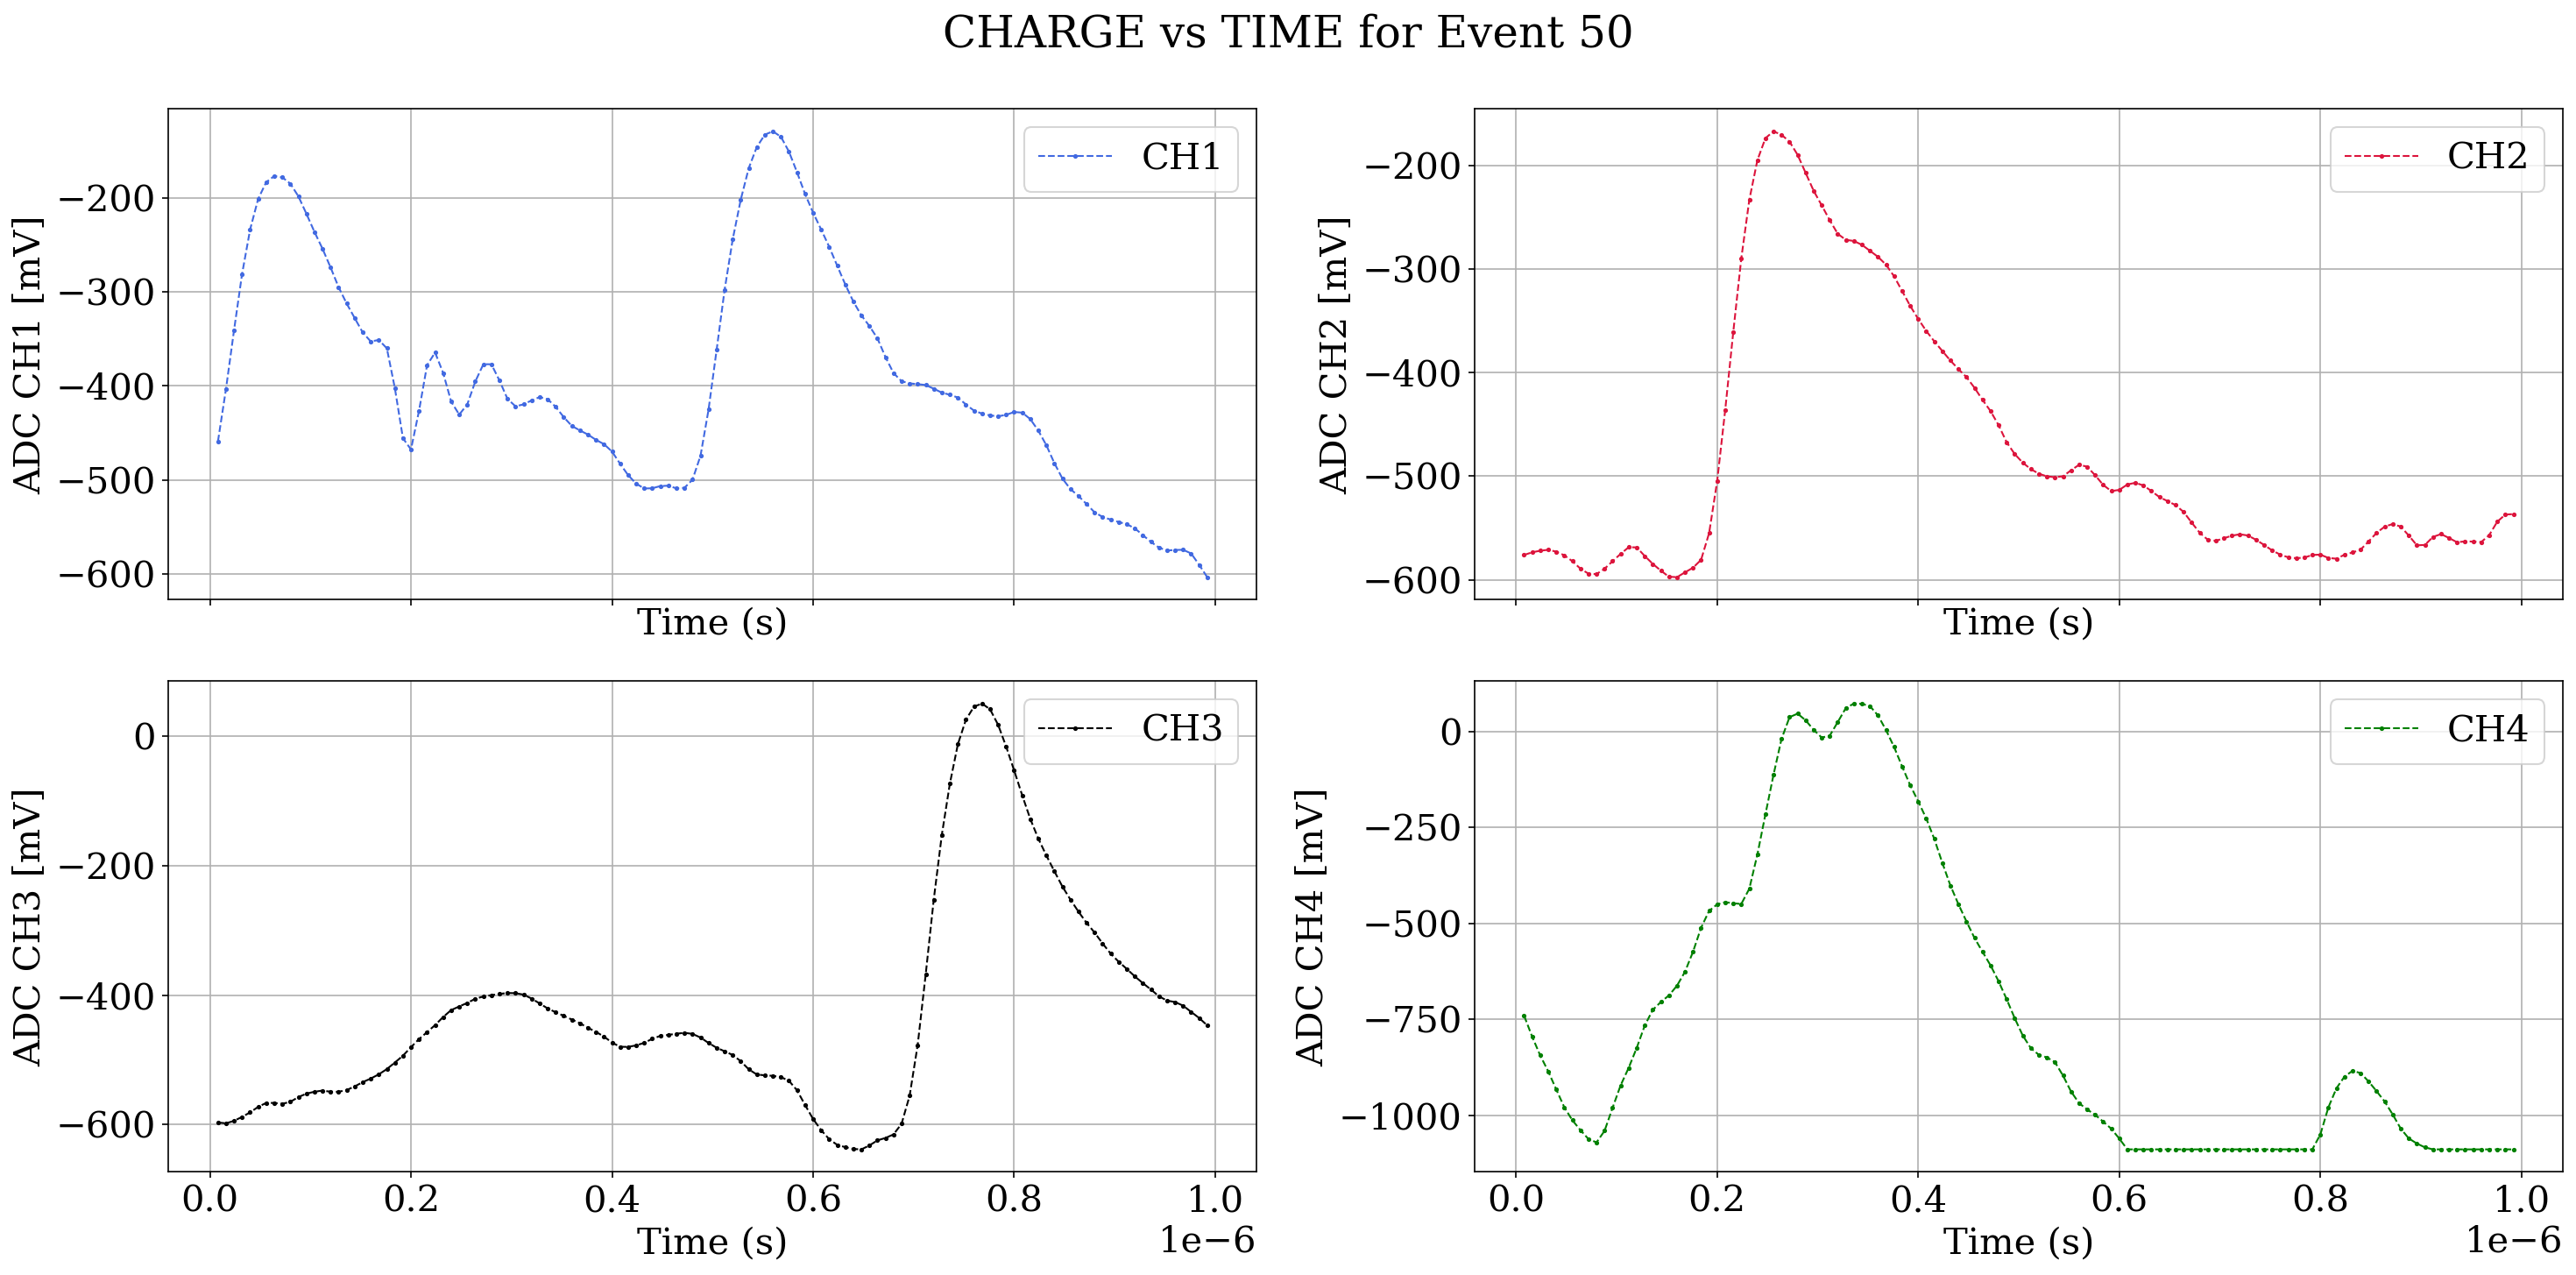

In [8]:
df_event = df[df['event'] == event_list[selected_event]]

fig, axs = plt.subplots(2, 2, figsize=(20, 10), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'CHARGE vs TIME for Event {event_list[selected_event]}')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    ax.plot(df_event['TIME'].values, df_event[ch].values,
            marker='.', linestyle='--', color=colors[i], markersize=3, linewidth=1, label=ch)
    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


##  Data filtering

In [9]:
0.2/1, 2/6


(0.2, 0.3333333333333333)

In [10]:
# Remove events with more than 4 peaks above threshold across all channels
def count_high_peaks(group, threshold=2000):
    peak_count = 0
    for ch in channels:
        peaks, _ = find_peaks(group[ch].values, height=threshold)
        peak_count += len(peaks)
    return peak_count

peak_counts  = df.groupby('event').apply(count_high_peaks)
valid_events = peak_counts[peak_counts <= 4].index

filtered_df = df[df['event'].isin(valid_events)]

event_list = filtered_df['event'].unique()
nevents    = len(event_list)
print(f'Events after filtering: {nevents}')


/tmp/ipykernel_909673/3951954891.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  peak_counts  = df.groupby('event').apply(count_high_peaks)


Events after filtering: 51993


##  Integration window

In [11]:
window_width = 20

t_matrix = filtered_df['TIME'].values.reshape(nevents, -1)
time     = t_matrix[0]


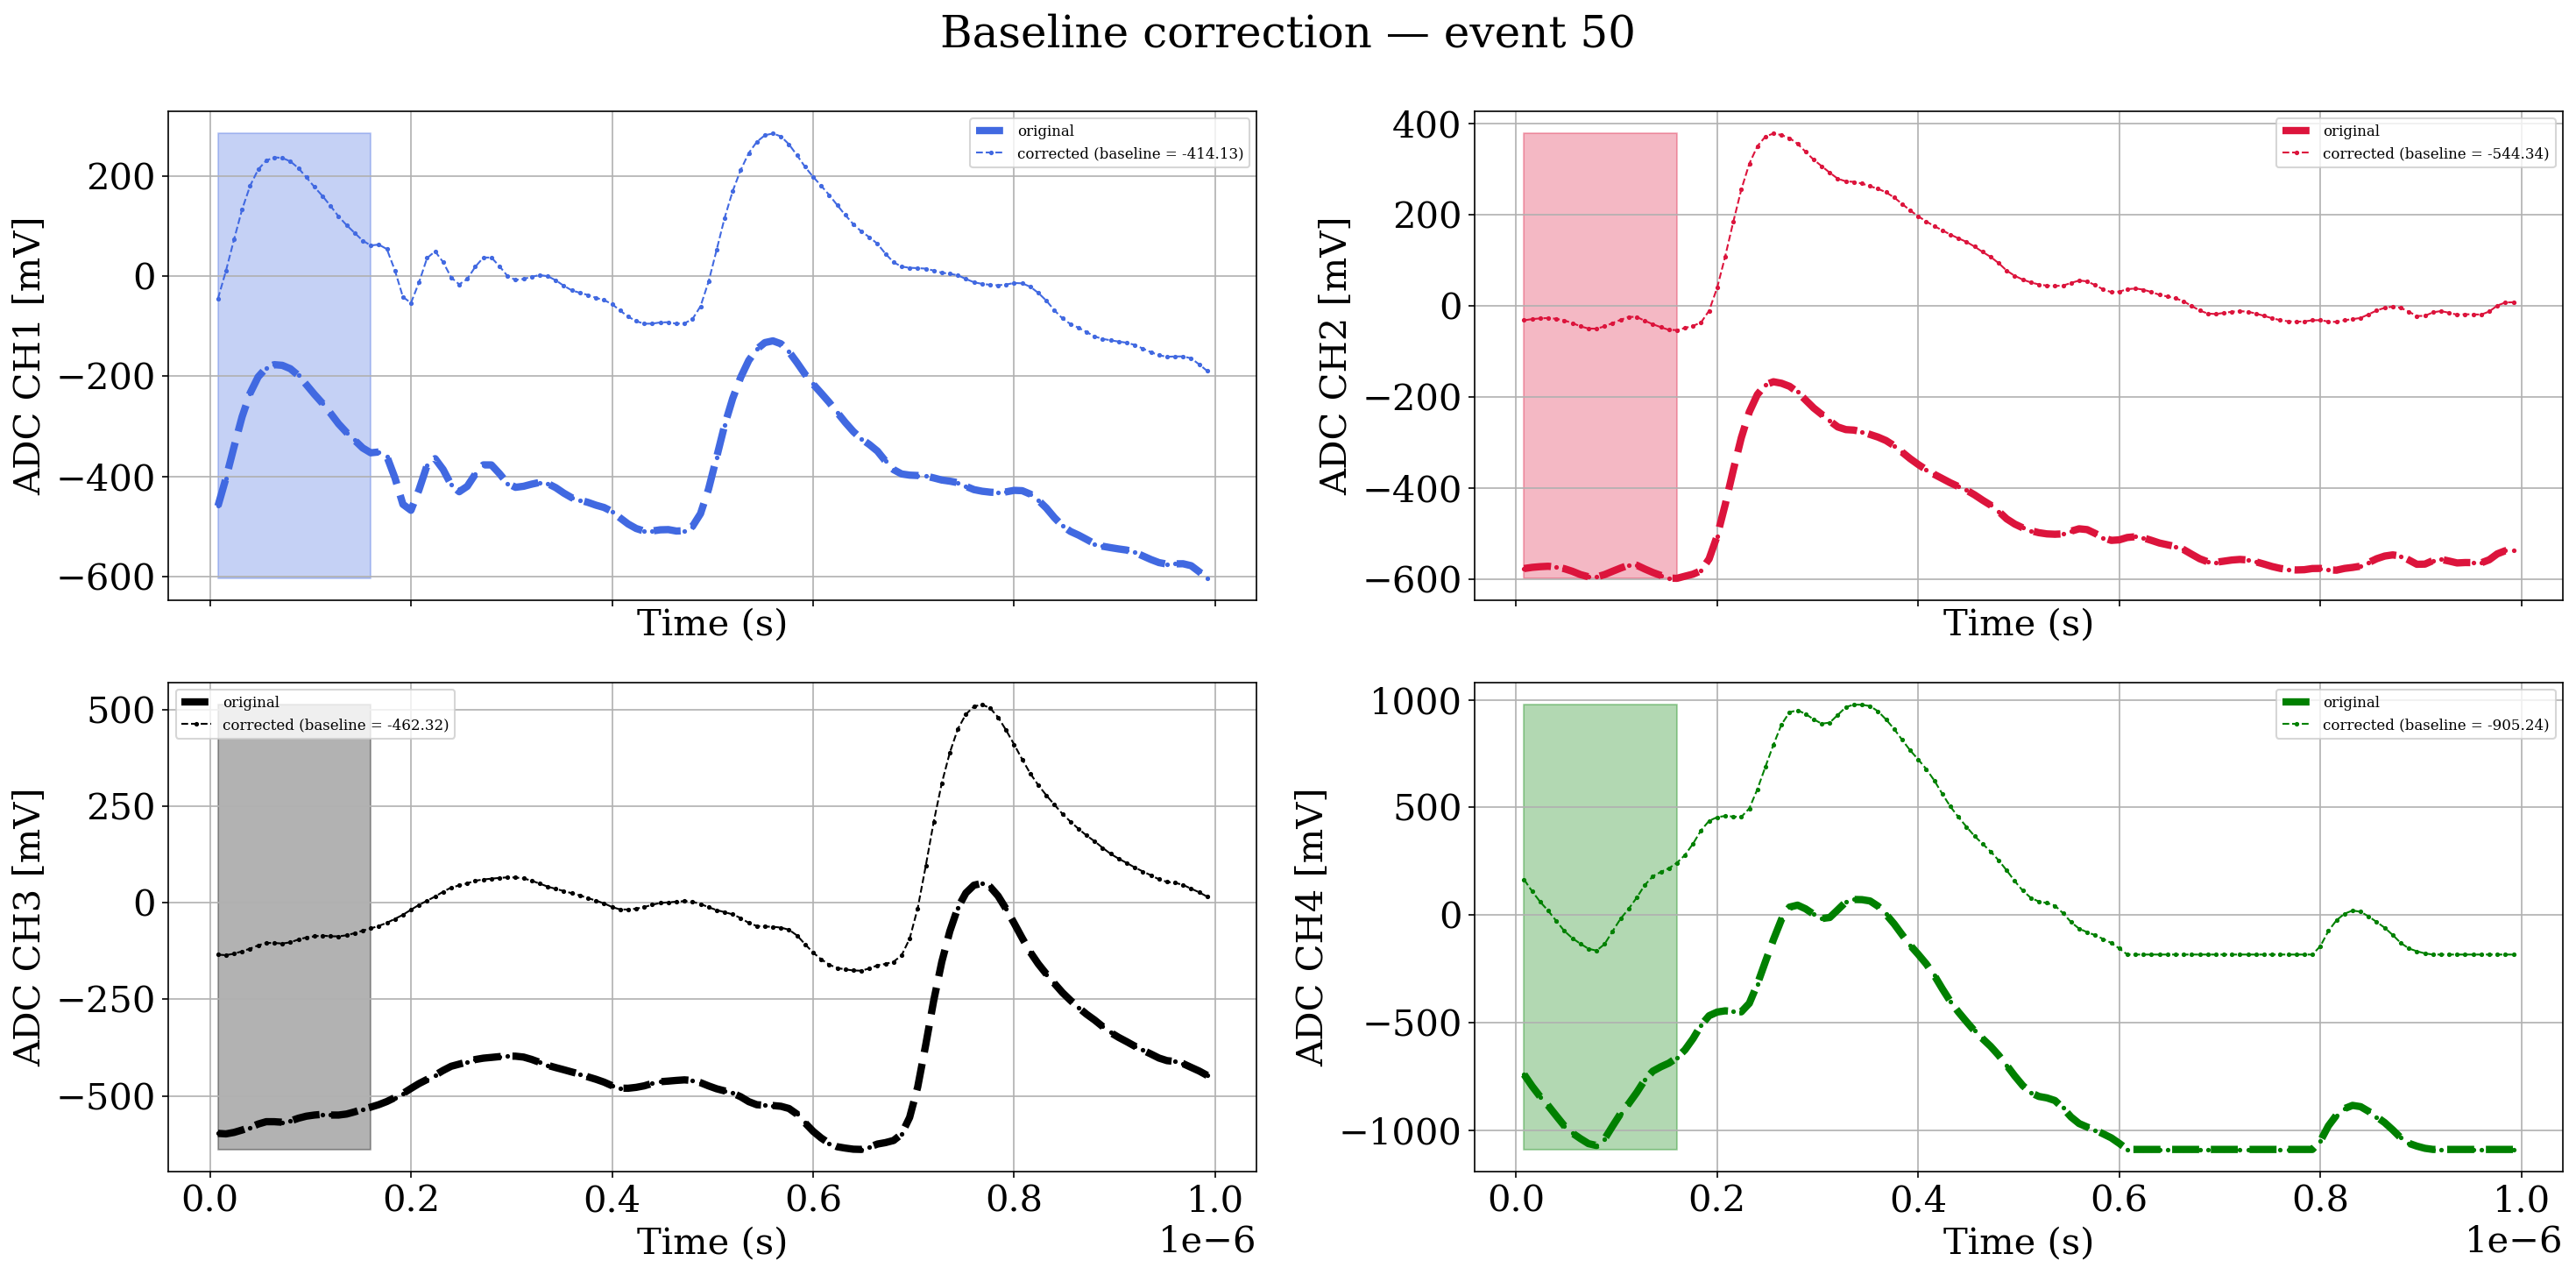

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(20, 10), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'Baseline correction — event {event_list[selected_event]}')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    voltage    = filtered_df[ch].values
    v_matrix   = voltage.reshape(nevents, -1)
    v_matrix_corrected, baselines, window = cig.BaselineCorrection(v_matrix, window=window_width)

    ax.plot(t_matrix[selected_event], v_matrix[selected_event],
            marker='.', linestyle='--', color=colors[i], markersize=3, linewidth=4, label='original')
    ax.plot(t_matrix[selected_event], v_matrix_corrected[selected_event],
            marker='.', linestyle='--', color=colors[i], markersize=3, linewidth=1,
            label=f'corrected (baseline = {baselines[selected_event]:.2f})')

    s = max(window[selected_event], 0)
    e = min(window[selected_event] + window_width, len(v_matrix[0]))
    ax.fill_between(time[s:e],
                    v_matrix[selected_event].min(),
                    v_matrix_corrected[selected_event].max(),
                    color=colors[i], alpha=0.3)

    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [13]:
# time_window = (0.18e-6 < time) & (time <= 0.45e-6)
# time_window = (0.18e-6 < time) & (time <= 0.8e-6)
time_window = (0.18e-6 < time) & (time <= 0.7e-6)


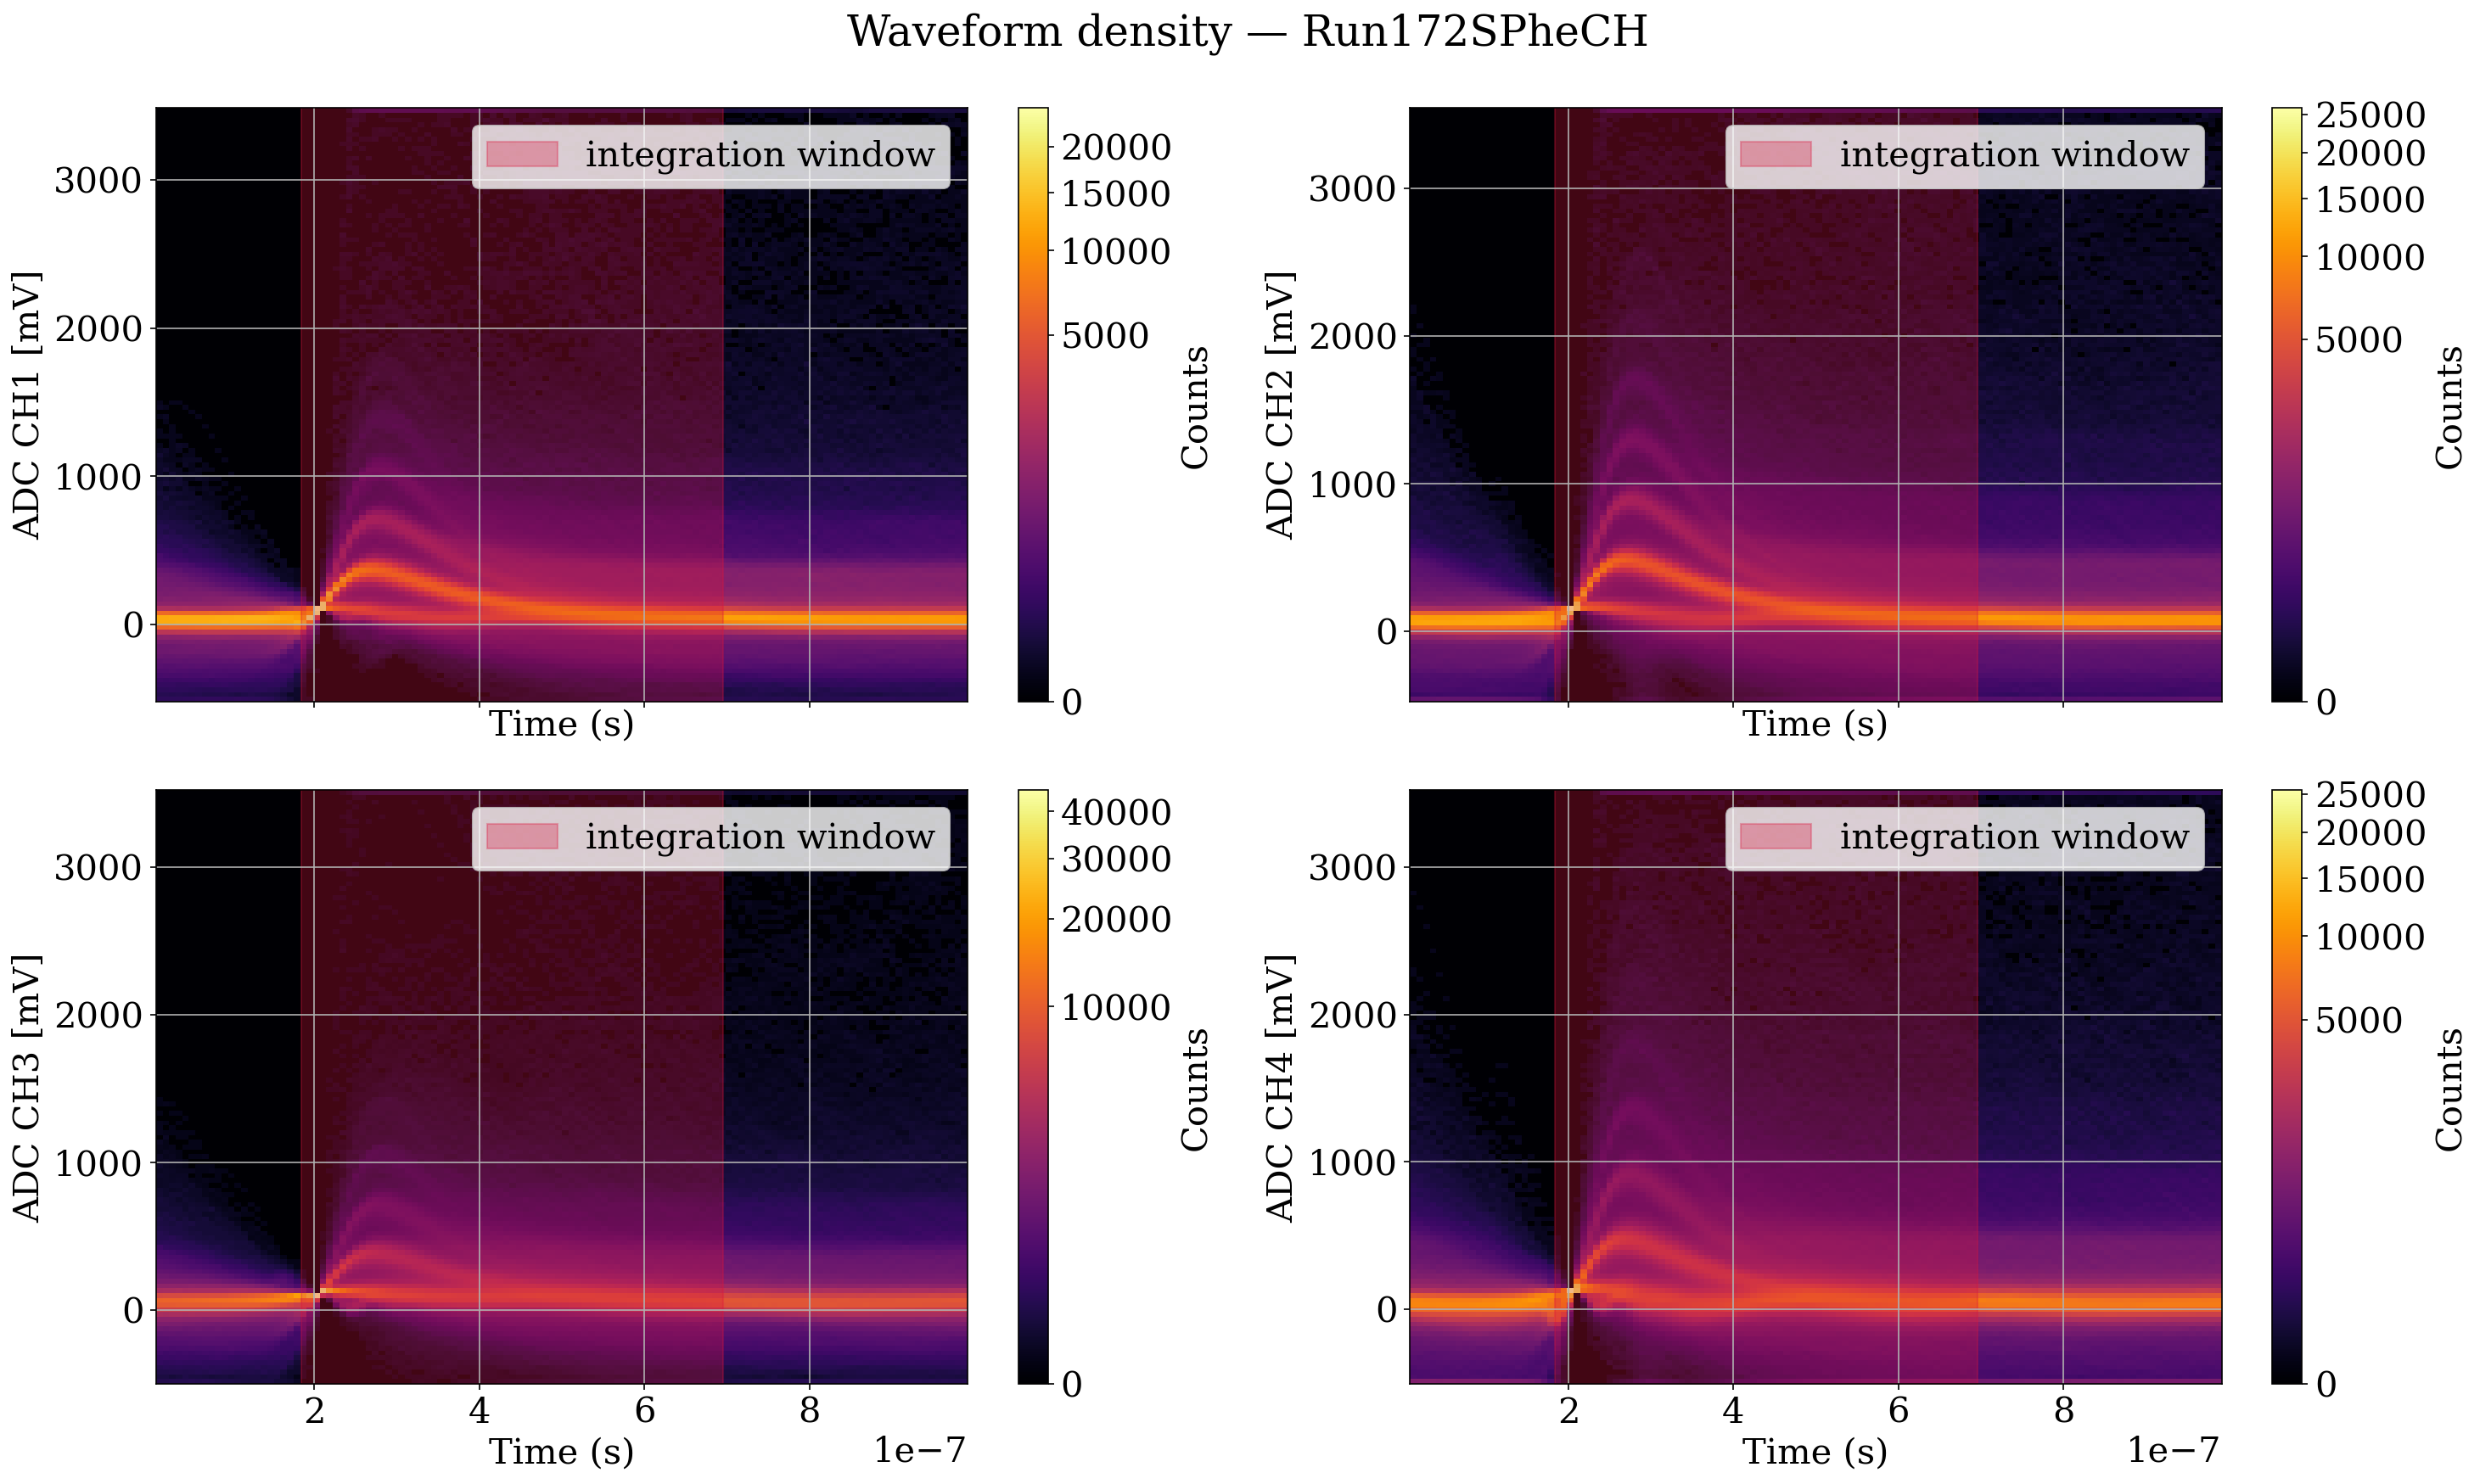

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(20, 12), dpi=150, sharex=True, sharey=False)
fig.suptitle(f'Waveform density — {run_base}')
axs_flat = axs.flatten()

for i, ch in enumerate(channels):
    ax = axs_flat[i]
    voltage            = filtered_df[ch].values
    v_matrix           = voltage.reshape(nevents, -1)
    v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]

    hb = ax.hist2d(t_matrix.flatten(), v_matrix_corrected.flatten(),
                   bins=[np.shape(t_matrix)[1], np.shape(v_matrix_corrected)[1]],
                   cmap='inferno', norm=mcolors.PowerNorm(gamma=0.3))
    fig.colorbar(hb[3], ax=ax, label='Counts')

    ax.fill_between(time[time_window],
                    v_matrix_corrected.min(), v_matrix_corrected.max(),
                    color=colors[1], alpha=0.3, label='integration window')

    ax.set_ylabel(f'ADC {ch} [mV]')
    ax.set_xlabel('Time (s)')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


# CHARGE

##  Finger Plot

In [71]:
def FingerPlot(df, channels, n_gaussians_list):
    """Charge finger plot for all channels in a 2x2 grid."""

    opt_A, opt_mu, opt_sigma, opt_mu_errors = {}, {}, {}, {}
    

    fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
    fig.suptitle(f'{run_base} — Charge Finger Plot')
    axs_flat = axs.flatten()

    for i, ch in enumerate(channels):
        ax = axs_flat[i]

        voltage            = df[ch].values
        v_matrix           = voltage.reshape(nevents, -1)
        v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]

        n_gaussians = n_gaussians_list[i]

        charge = np.trapz(v_matrix_corrected[:, time_window],
                          x=time[time_window], axis=1)

        # Per-channel hist range (CH1 behaves differently from the others)
        if i<2:
            hist_range = (0, 3.e-4)
        else:
            hist_range = (-1e-5, 2.1e-4)

        events_hist, bins, _ = ax.hist(charge,
                                       bins=int(np.sqrt(len(charge))),
                                       range=hist_range,
                                       density=False,
                                       alpha=0.3,
                                       label=ch)

        bins_means = (bins[:-1] + bins[1:]) / 2

        # Find peaks
        if i<2:
            peak_distance = 40
        else:
            peak_distance = 60
        peaks, _ = find_peaks(events_hist, distance=peak_distance, prominence=0.5)
        # ax.plot(bins_means[peaks], events_hist[peaks], 'or', alpha = 0.3, markersize = 10)

        msk = ((bins_means > (bins_means[events_hist.argmax()] + bins_means[0]) * 0.15) &
               (bins_means < bins_means[peaks[n_gaussians - 1]] * 1.15))

        x = bins_means[msk]
        y = events_hist[msk]

        initial_guess_A     = list(events_hist[peaks][:n_gaussians])
        initial_guess_mu    = list(bins_means[peaks][:n_gaussians])
        initial_guess_sigma = [0.6 * (bins_means[1] - bins_means[0])] * n_gaussians
        initial_guess       = initial_guess_A + initial_guess_mu + initial_guess_sigma

        params, covariance = curve_fit(cig.sum_of_gaussians, x, y, p0=initial_guess, maxfev=100000)

        for j in range(10):
            lower  = np.minimum(params * 0.8, params * 1.2)
            upper  = np.maximum(params * 0.8, params * 1.2)
            bounds = (lower, upper)
            params, covariance = curve_fit(cig.sum_of_gaussians, x, y,
                                           p0=params, bounds=bounds, maxfev=100000)

        opt_A[ch]          = params[:n_gaussians]
        opt_mu[ch]         = params[n_gaussians:2*n_gaussians]
        opt_sigma[ch]      = params[2*n_gaussians:]
        opt_mu_errors[ch]  = np.sqrt(np.diag(covariance)[n_gaussians:2*n_gaussians])

        gaussian_sum = cig.sum_of_gaussians(x, *params)
        ax.plot(x, gaussian_sum, lw=3, alpha=0.8, label='Gaussian Fit')

        for jj, mu in enumerate(opt_mu[ch]):
            ax.plot(mu, cig.sum_of_gaussians(mu, *params), 'X',
                    color=colors[jj],
                    label=fr"$\mu_{{{jj+1}}}$ = {mu:.2E} [V·s]",
                    markersize=10)
            one_g = [opt_A[ch][jj], opt_mu[ch][jj], opt_sigma[ch][jj]]
            ax.plot(x, cig.sum_of_gaussians(x, *one_g), '--', color=colors[jj])

        ax.set_title(ch)
        ax.set_xlabel(r'Charge [mV·s]')
        ax.set_ylabel('Counts')
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return opt_A, opt_mu, opt_sigma, opt_mu_errors


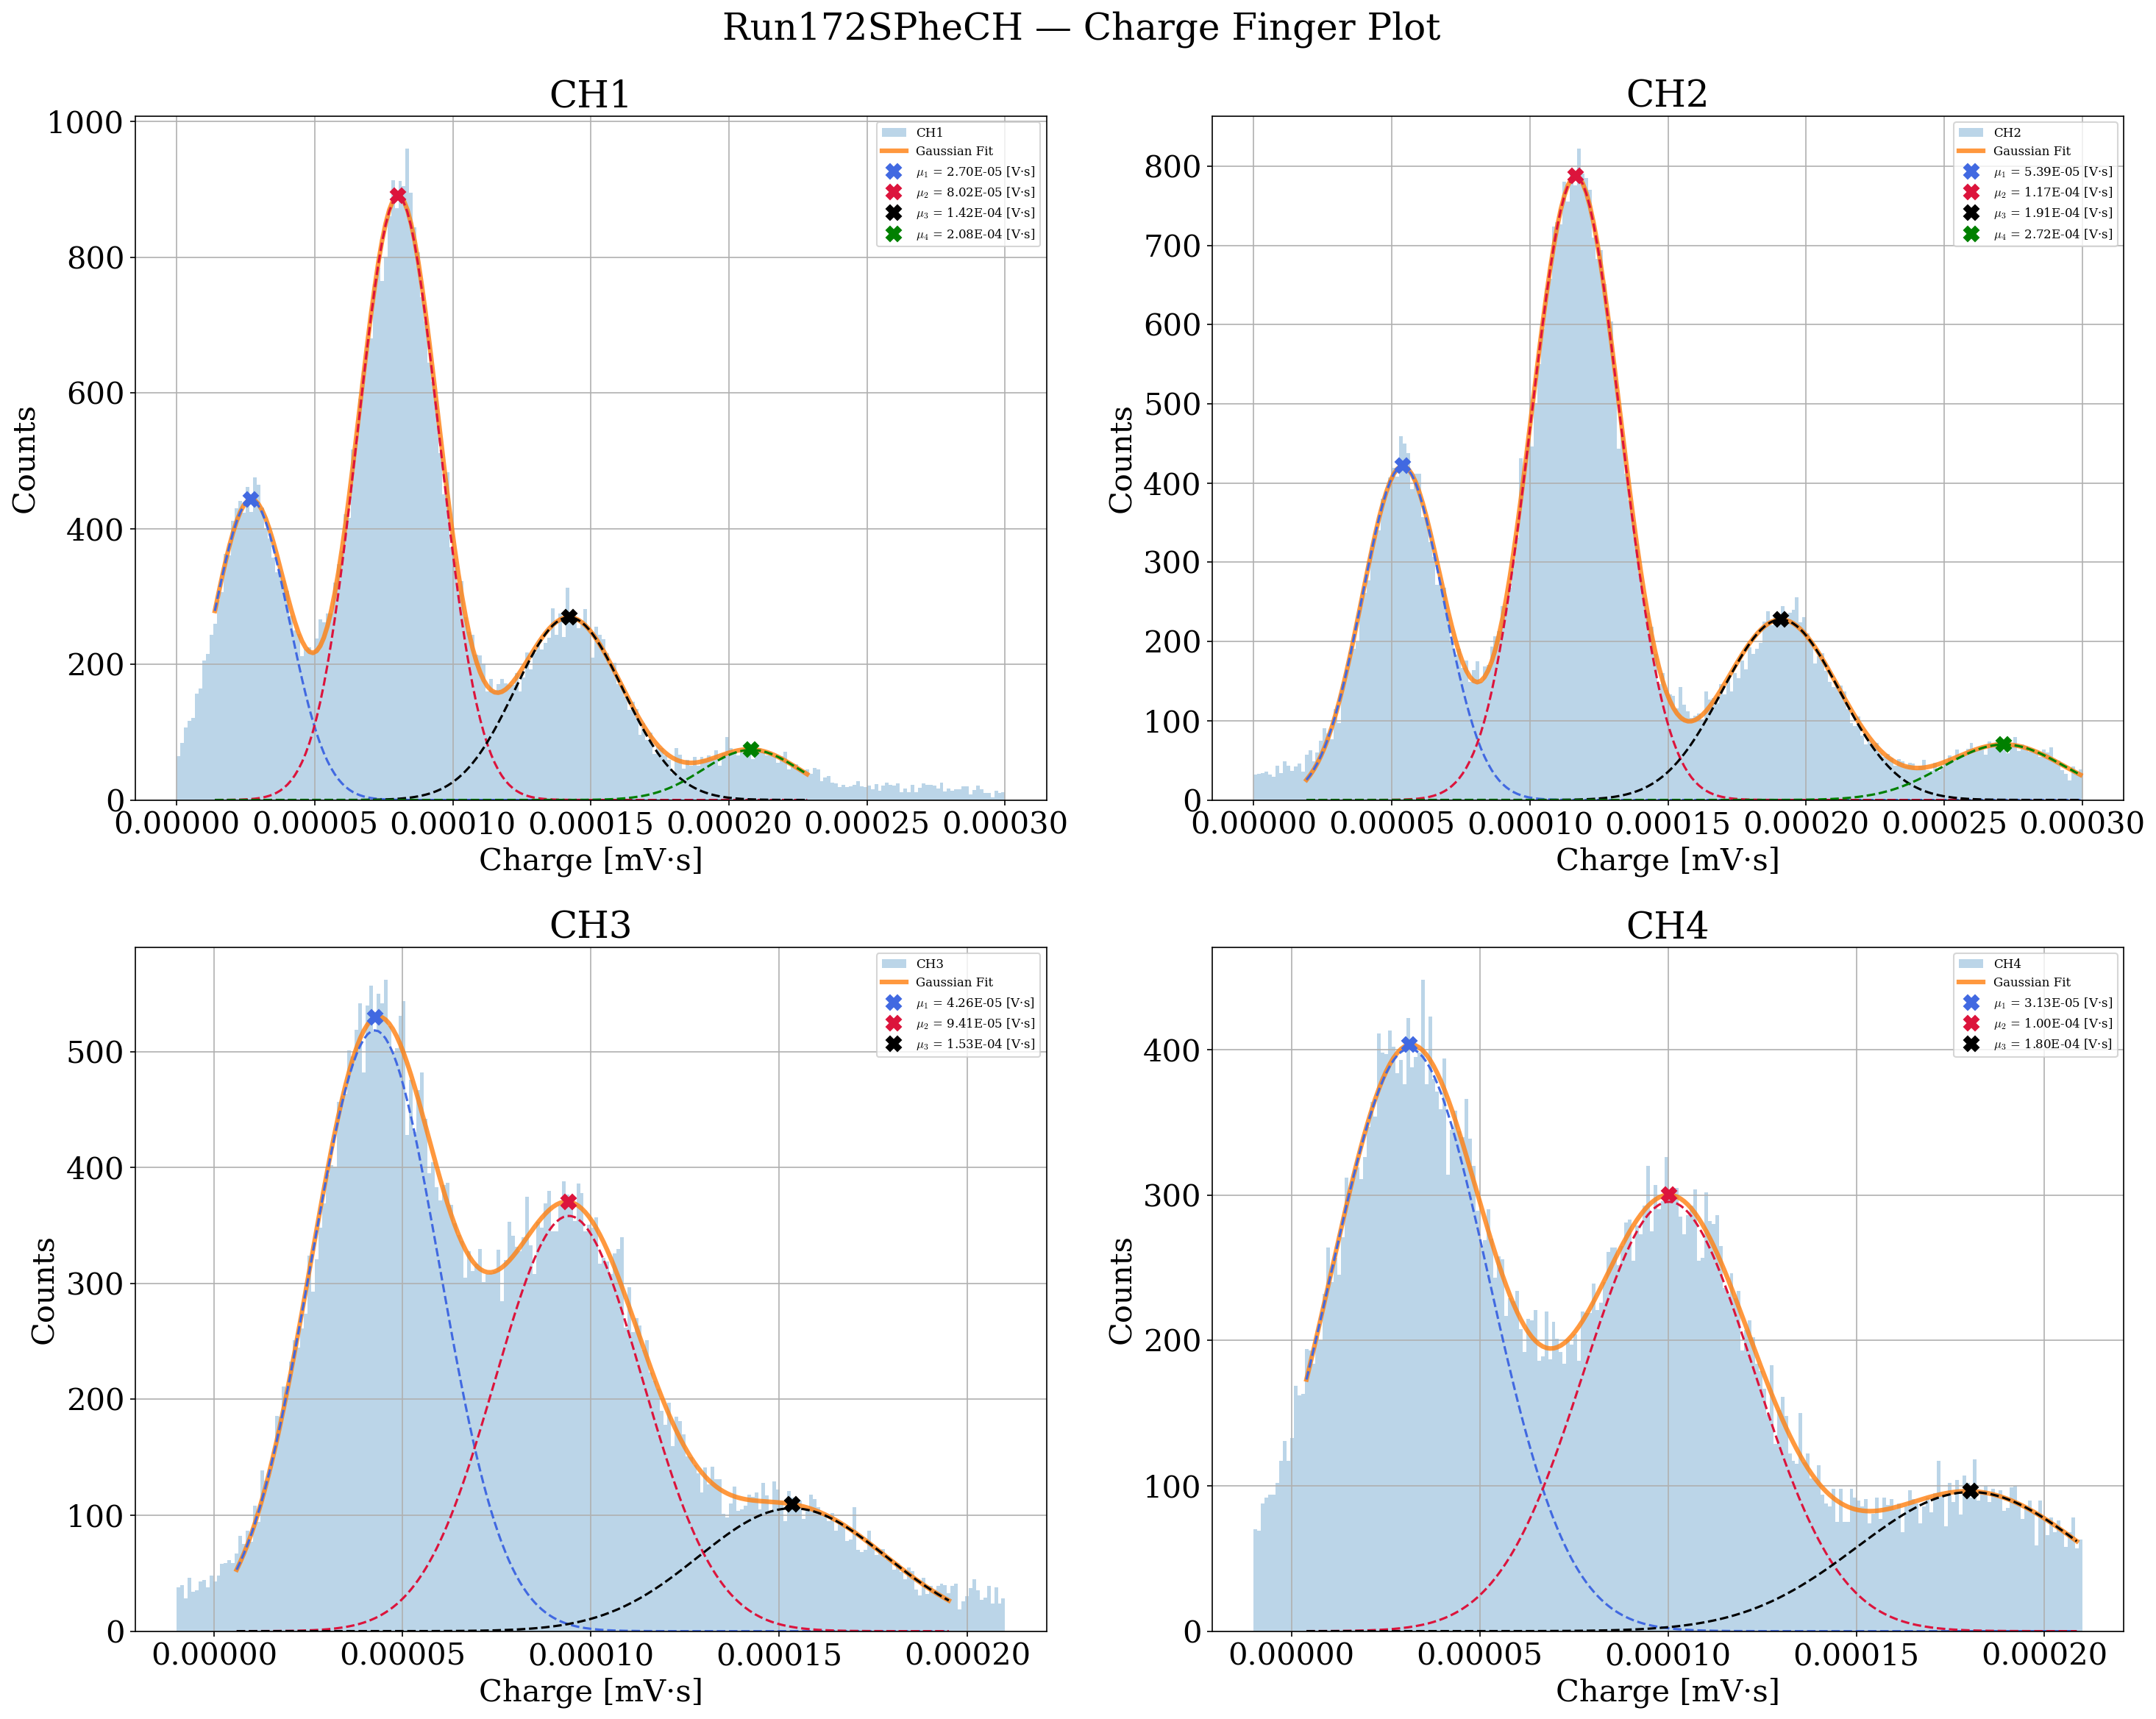

In [72]:
n_gaussians = [4, 4, 3, 3]
opt_A, opt_mu, opt_sigma, opt_mu_errors = FingerPlot(filtered_df, channels, n_gaussians)


##  Data Analysis: Linearity

In [73]:
opt_mu


{'CH1': array([2.69510938e-05, 8.02054070e-05, 1.42058062e-04, 2.08100330e-04]),
 'CH2': array([5.38791562e-05, 1.16573228e-04, 1.90889657e-04, 2.71701657e-04]),
 'CH3': array([4.26455945e-05, 9.41398998e-05, 1.53497047e-04]),
 'CH4': array([3.13236654e-05, 1.00290870e-04, 1.80422271e-04])}

In [74]:
pes_spectrum = opt_mu
err_spectrum = opt_mu_errors


In [75]:
# npeaks = -1  # all except last one
npeaks = None   # all


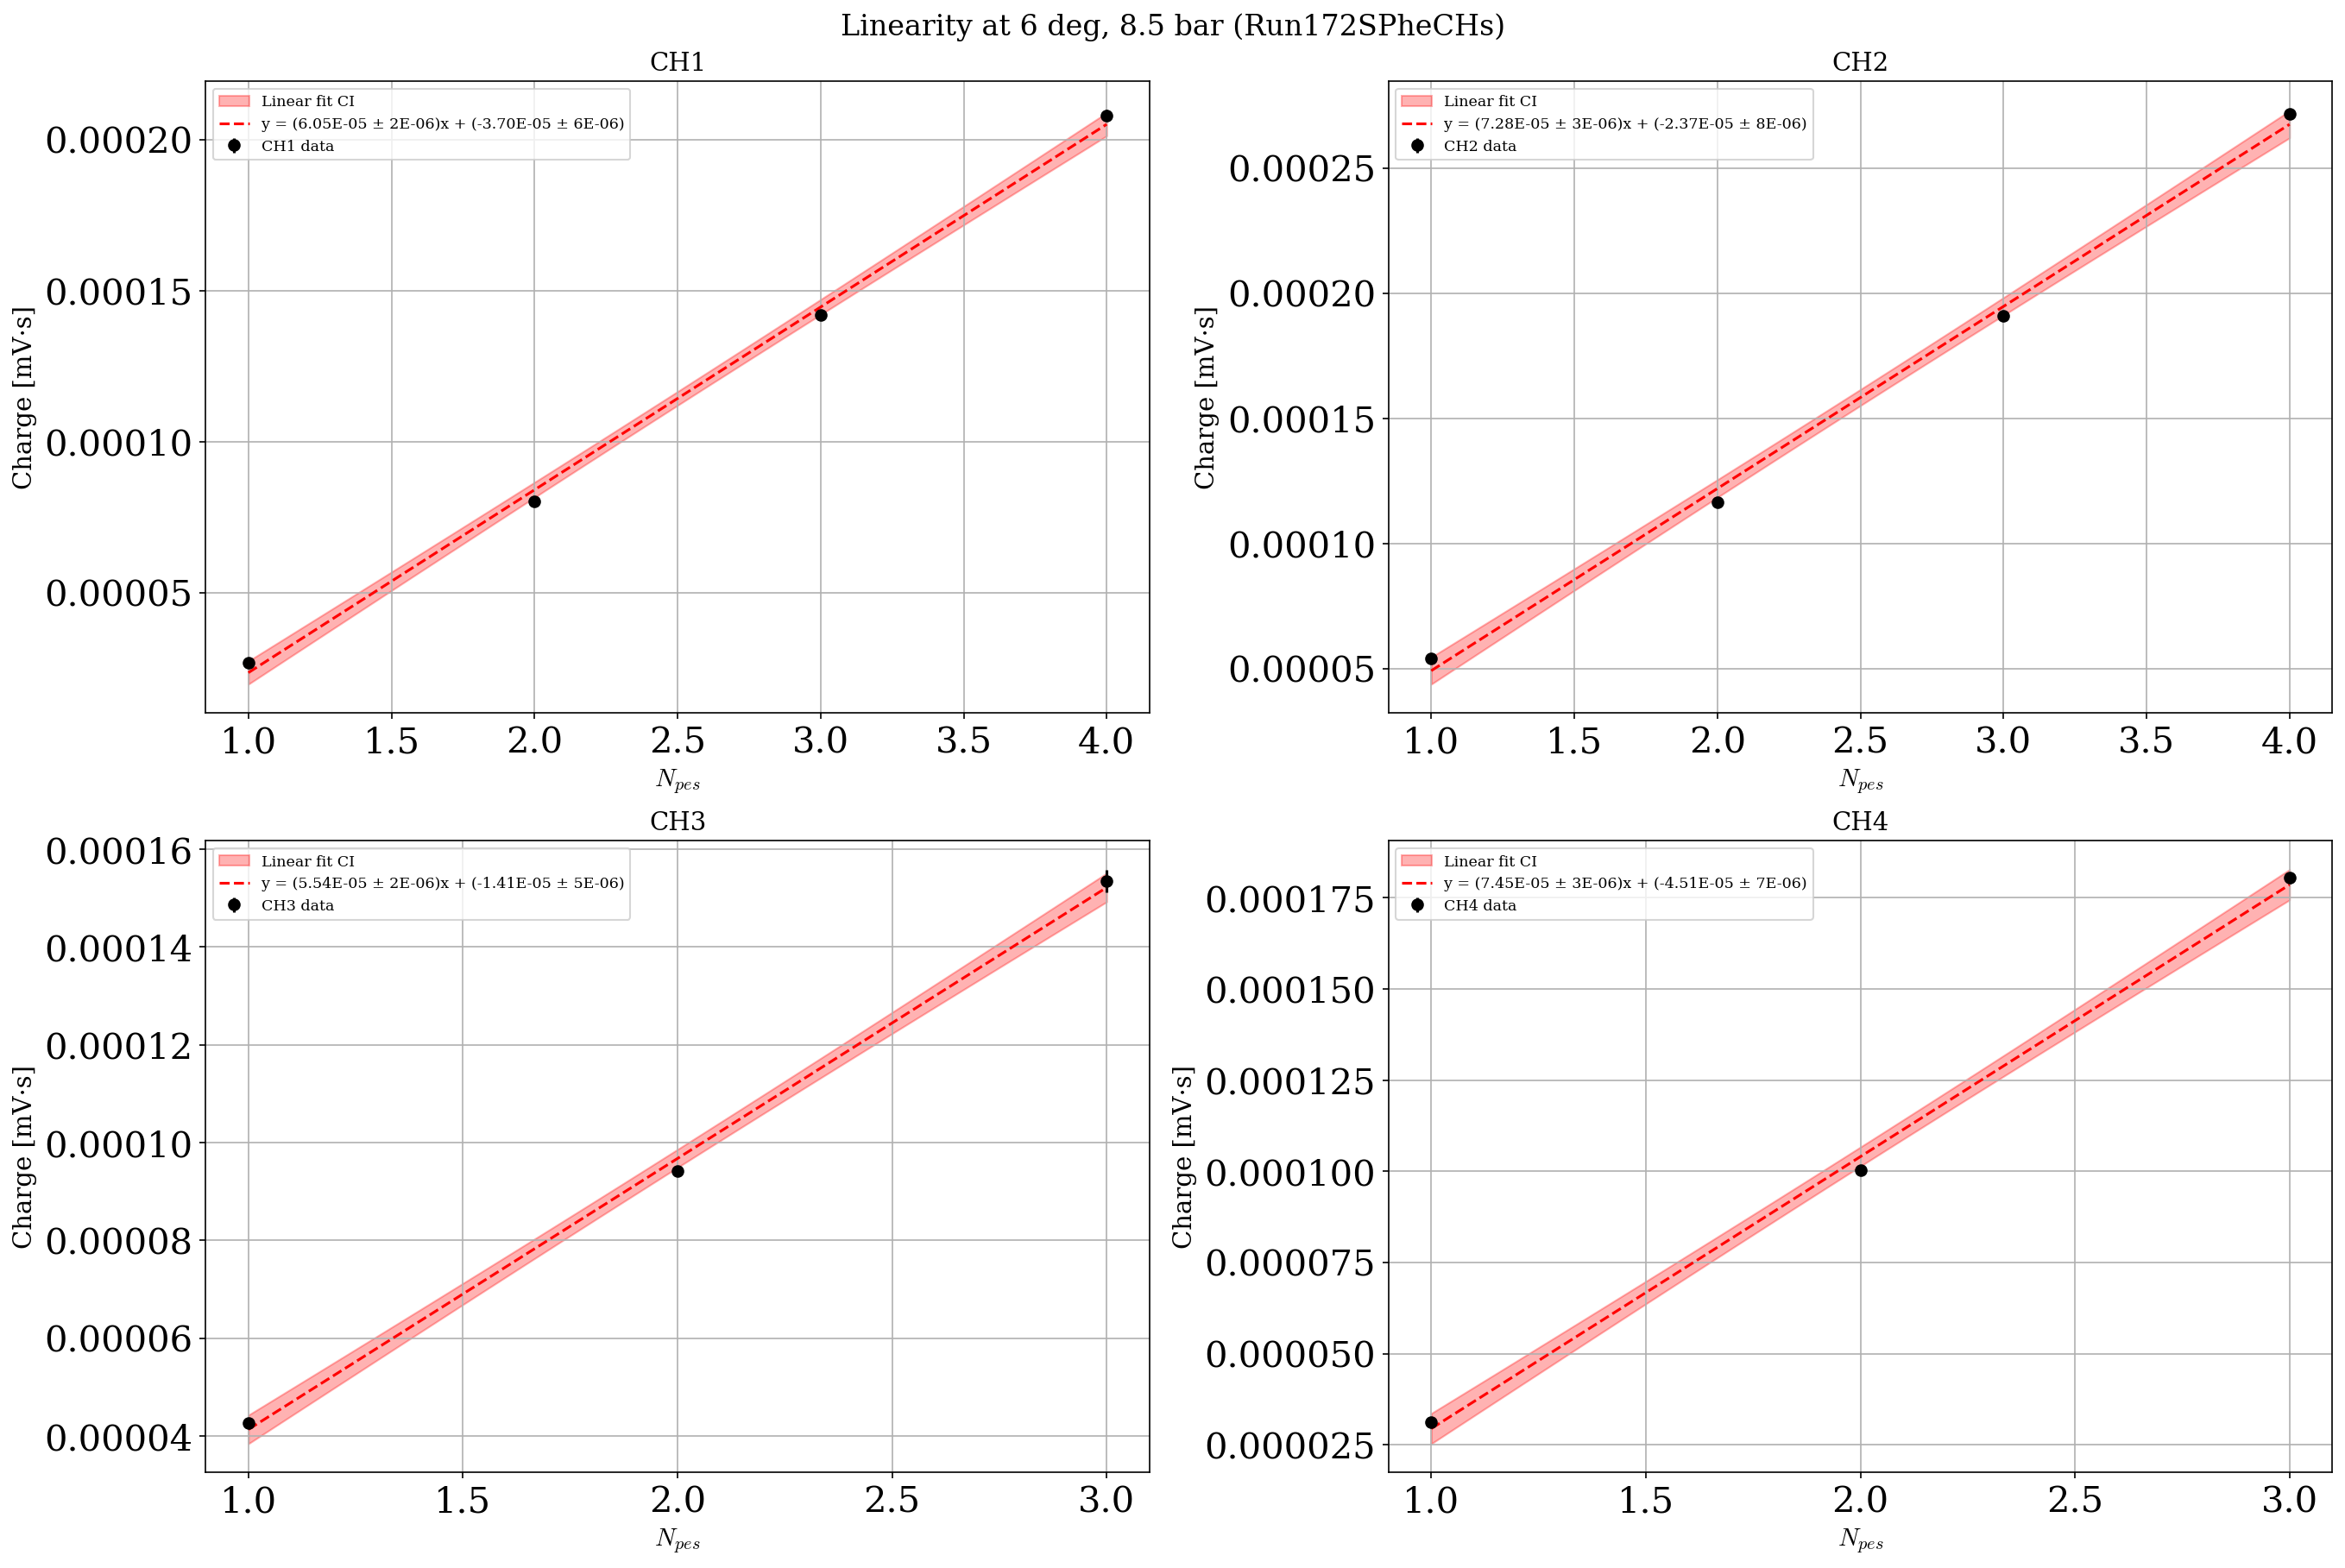

In [77]:
fig, axs = plt.subplots(2, 2, figsize=(18, 12), dpi=150, constrained_layout=True)
fig.suptitle(f'Linearity at {temperature} deg, {pressure} bar ({run_base}s)', fontsize=16)
axs_flat = axs.flatten()
font_size = 14

for idx, ch in enumerate(pes_spectrum.keys()):
    ax = axs_flat[idx]

    x = np.arange(len(pes_spectrum[ch][:npeaks])) + 1
    y = pes_spectrum[ch][:npeaks]
    order = np.argsort(y)
    y = y[order]

    params, cov = np.polyfit(x, y, 1, cov=True)
    slope, intercept = params
    slope_err     = np.sqrt(cov[0, 0])
    intercept_err = np.sqrt(cov[1, 1])

    x_fit     = np.linspace(min(x), max(x), 200)
    y_fit     = slope * x_fit + intercept
    y_fit_var = (x_fit**2) * cov[0,0] + cov[1,1] + 2 * x_fit * cov[0,1]
    y_fit_err = np.sqrt(y_fit_var)

    ax.errorbar(x, y, yerr=err_spectrum[ch][:npeaks][order],
                fmt='o', alpha=1, color='k', label=f'{ch} data')
    ax.fill_between(x_fit, y_fit - y_fit_err, y_fit + y_fit_err,
                    color='r', alpha=0.3, label='Linear fit CI')
    ax.plot(x_fit, y_fit, '--r',
            label=f'y = ({slope:.2E} ± {slope_err:.0E})x + ({intercept:.2E} ± {intercept_err:.0E})')

    ax.set_title(ch, fontsize=font_size)
    ax.set_xlabel(r'$N_{pes}$', fontsize=font_size)
    ax.set_ylabel(r'Charge [mV·s]', fontsize=font_size)
    ax.grid(True)
    ax.legend(fontsize=font_size * 0.6, loc='upper left')

plt.show()


# PEAK VOLTAGE

##  Finger Plot

In [21]:
def FingerPlotVoltage(df, channels, n_gaussians):
    """Peak-voltage finger plot for all channels in a 2x2 grid."""

    opt_A, opt_mu, opt_sigma, opt_mu_errors = {}, {}, {}, {}

    fig, axs = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
    fig.suptitle(f'{run_base} — Peak Voltage Finger Plot')
    axs_flat = axs.flatten()

    for i, ch in enumerate(channels):
        ax = axs_flat[i]

        voltage            = df[ch].values
        v_matrix           = voltage.reshape(nevents, -1)
        v_matrix_corrected = v_matrix - fixBaselines_Amp[ch]

        peak_mV = np.max(v_matrix[:, time_window], axis=1)

        events_hist, bins, _ = ax.hist(peak_mV,
                                       bins=int(np.sqrt(len(peak_mV))),
                                       range=(-450, 1000),
                                       density=False,
                                       alpha=0.3,
                                       label=ch)

        bins_means = (bins[:-1] + bins[1:]) / 2

        ax.axvline(200, color='red', linestyle='--', lw=2, label='Current signal trigger')

        ax.set_title(ch)
        ax.set_xlabel('Peak value [mV]')
        ax.set_ylabel('Counts')
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return opt_A, opt_mu, opt_sigma, opt_mu_errors


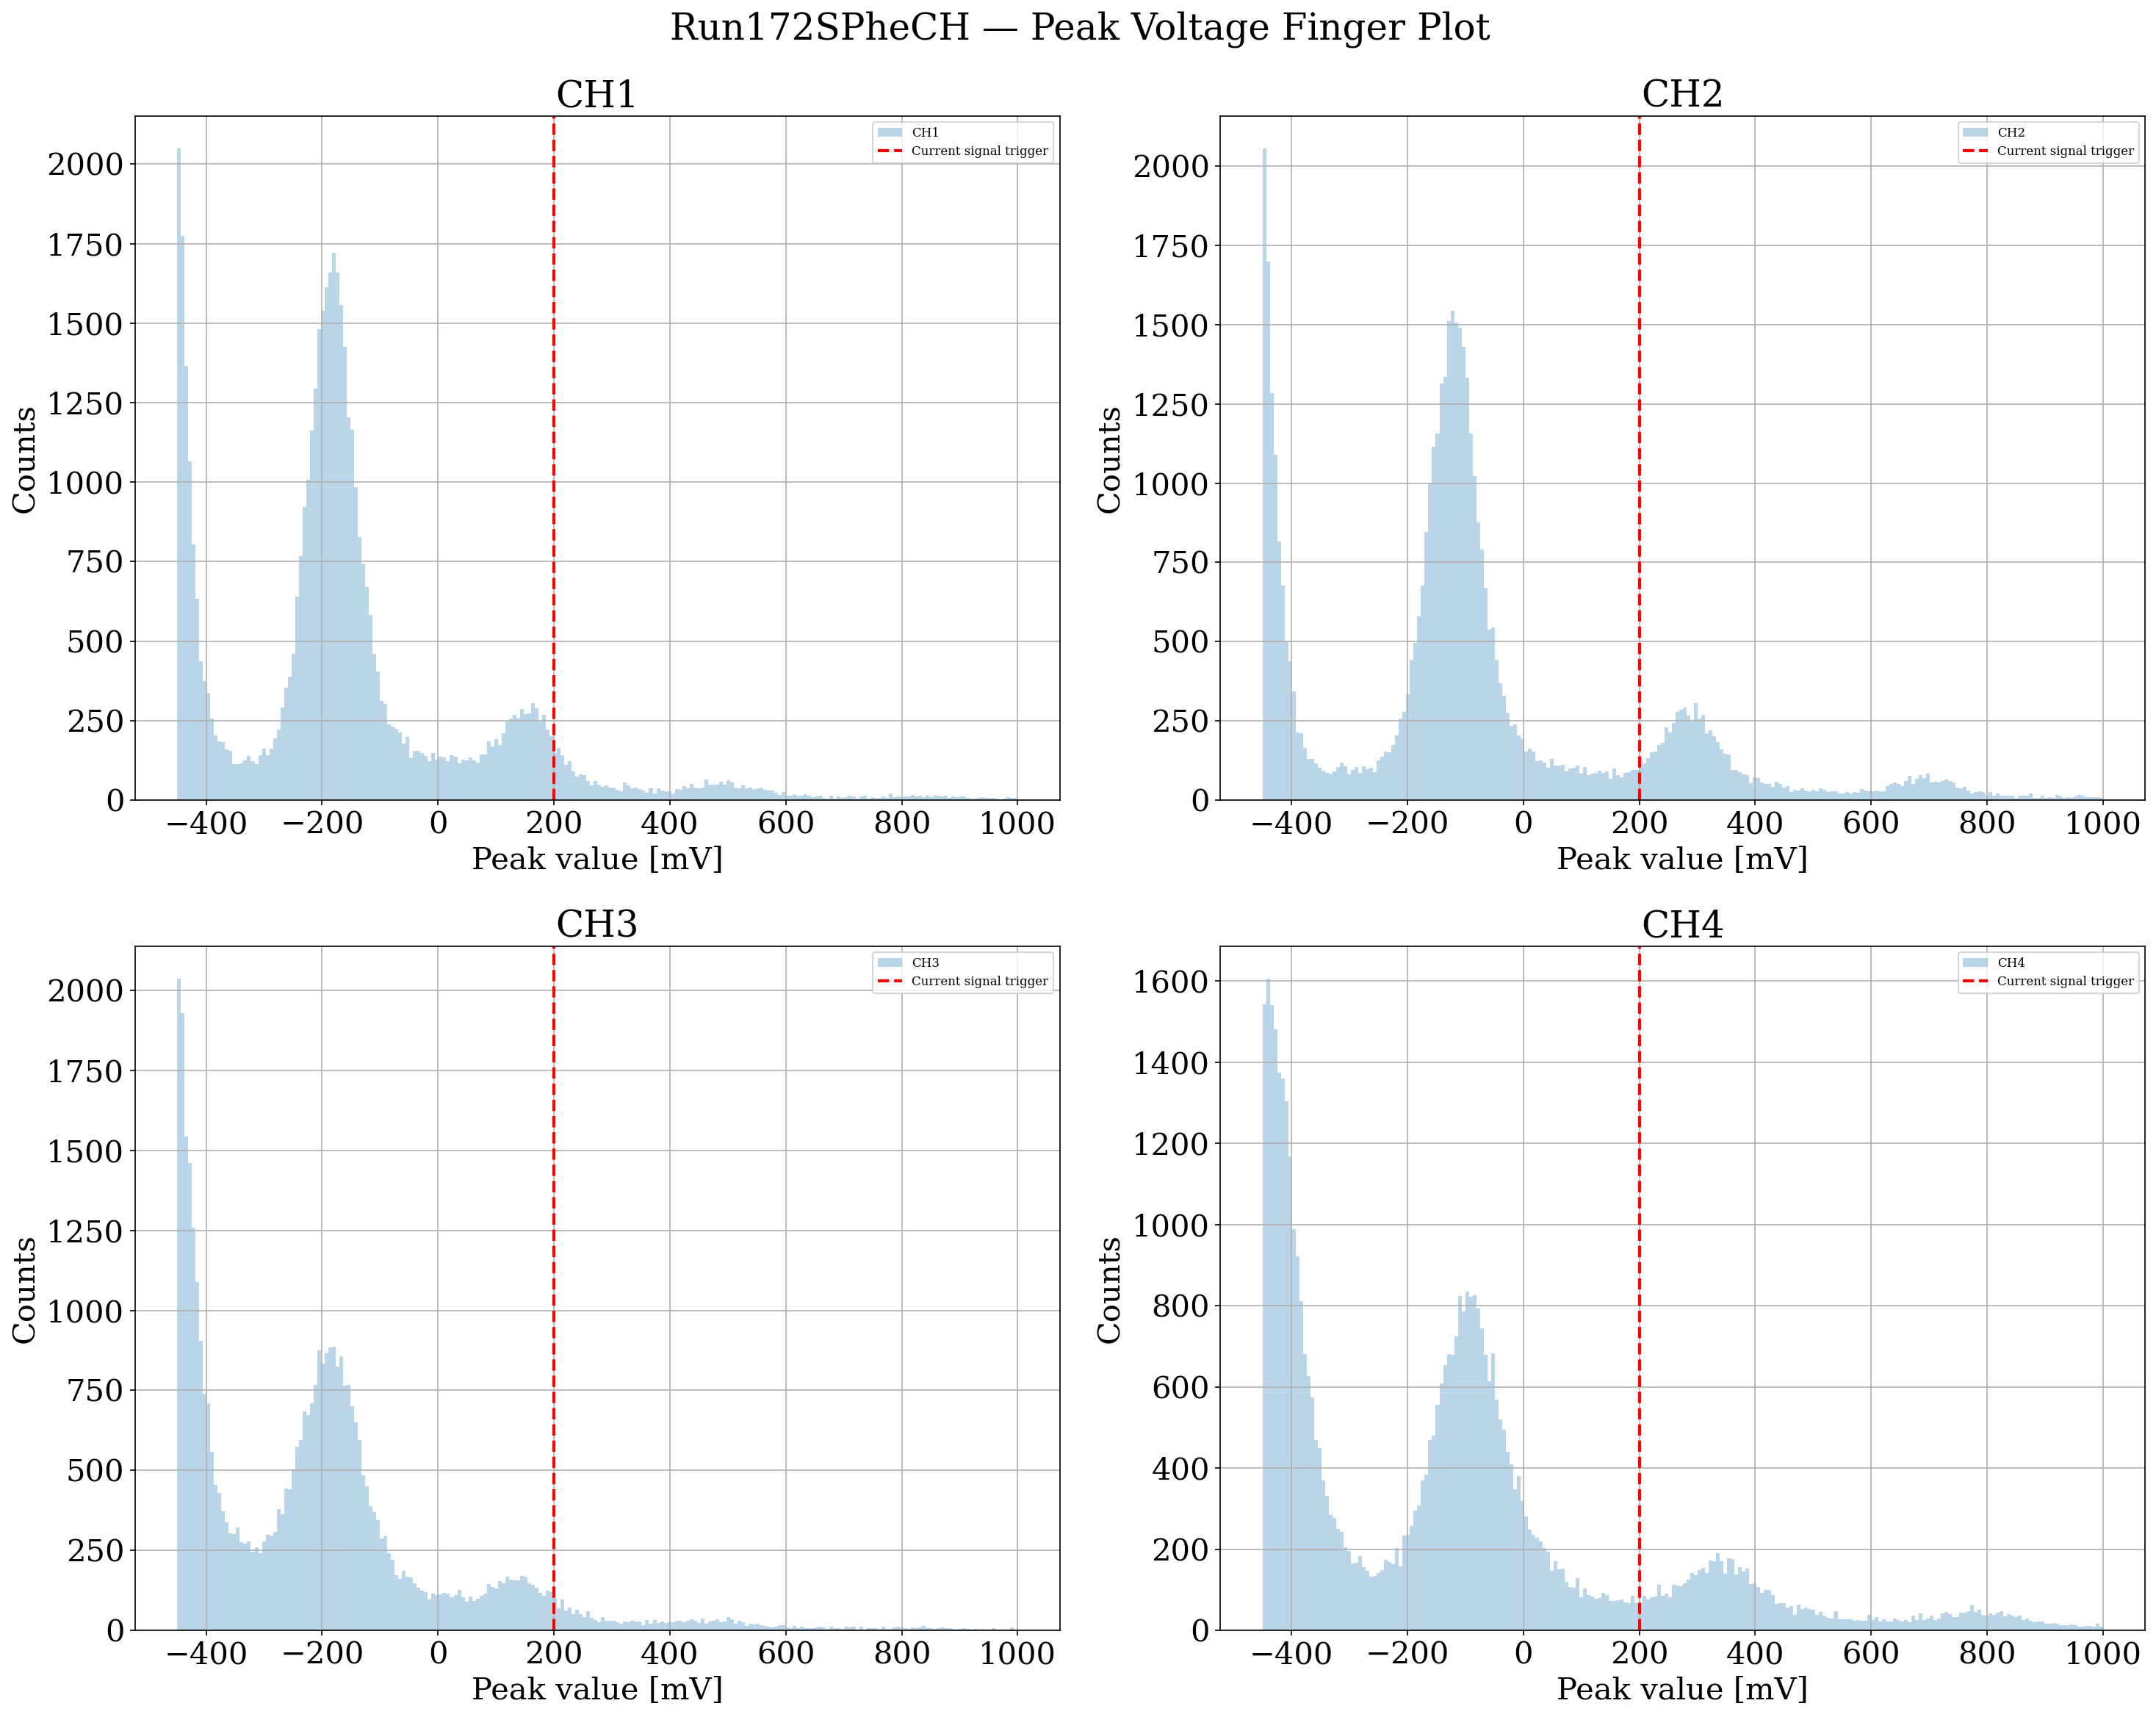

In [22]:
n_gaussians = 2
opt_A, opt_mu, opt_sigma, opt_mu_errors = FingerPlotVoltage(filtered_df, channels, n_gaussians)
